<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Custom Datasets

In [1]:
import torch
from torch import nn

In [2]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import requests
import zipfile
from pathlib import Path

# Let's setup the path to data folder
data_path= Path("data/")
image_path= data_path / "pizza_steak_sushi"

# Does the folder exist? If not, download it
if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents= True, exist_ok= True)

  # Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref.extractall(image_path)



Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [4]:
#LLet's see what does the directory we just uploaded look like
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are { len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.


In [5]:
# setup training & testing paths
train = image_path / "train"
test = image_path / "test"

train, test

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [6]:
print(f"We have total of {len(list(image_path.glob("*/*/*.jpg")))} images as data points")

We have total of 300 images as data points


Random image path: data/pizza_steak_sushi/test/sushi/2276986.jpg
Random image shape: (512, 512)
Random image class: sushi


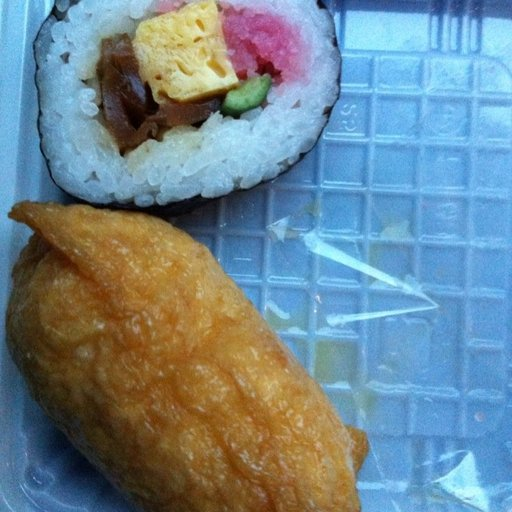

In [7]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob('*/*/*.jpg'))
random_img= random.choice(image_path_list)
img_class=  random_img.parent.stem
img =Image.open(random_img)

# print image metadata
print(f"Random image path: {random_img}")
print(f"Random image shape: {(img.height, img.width)}")
print(f"Random image class: {img_class}")

img

## Let's transform the data and get it ready for training

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [9]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

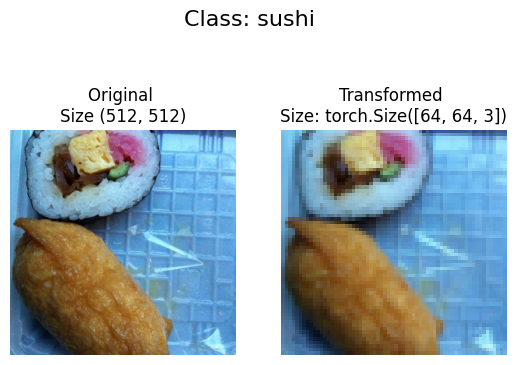

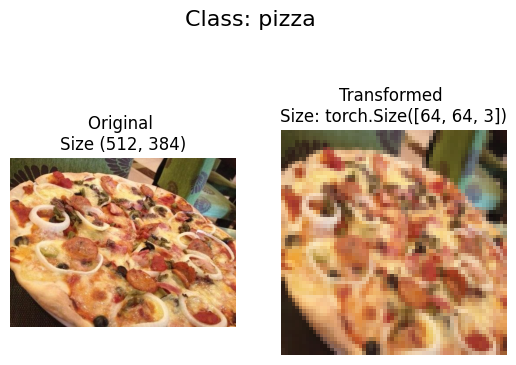

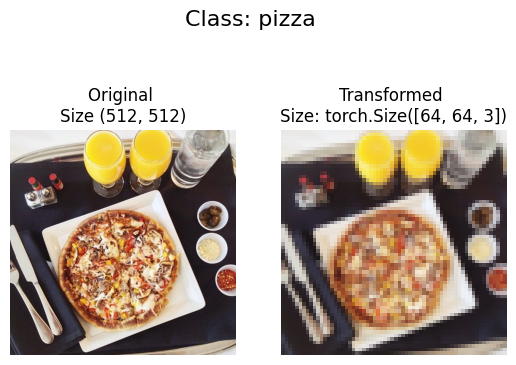

In [10]:
def plot_transformed_images(image_path_list, transform, n=3, seed=42):

  random.seed(seed)
  random_image_paths= random.sample(image_path_list, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize {f.size}")
      ax[0].axis("off")

      # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
      transformed_image= transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, data_transform)


## Let's load the data

In [11]:
# Using ImageFolder since the dataset is in standard image classification format
train_data= datasets.ImageFolder(root= train,
                                 transform= data_transform,
                                 target_transform= None)

test_data= datasets.ImageFolder(root= test,
                                transform= data_transform)
print(f"Train data:\n {train_data}\nTest data:\n {test_data}")

Train data:
 Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
 Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [12]:
class_names= train_data.classes
class_dict= train_data.class_to_idx
class_names, class_dict


(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

**Note: following up on the resize from 512x512 to 64x64:**
if you think the image is harder to recognize what's going on, chances are a model will find it harder to understand too.

In [13]:
from torch.utils.data import DataLoader
train_dataloader= DataLoader(dataset= train_data,
                             batch_size=1,
                             num_workers= os.cpu_count(),
                             shuffle= True)
test_dataloader= DataLoader(dataset= test_data,
                            batch_size=1,
                            num_workers= os.cpu_count(),
                            shuffle= False)

# What if we create a custom dataset

In [14]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [15]:
# Helper function: make a function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:

  classes= sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

  class_to_idx= {cls_name: i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx

In [16]:
find_classes(train)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### Let's build torchvision.datasets.ImageFolder from scratch

In [17]:
list(train.glob('*/*.jpg'))[0].parent.name

'pizza'

In [18]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

  def __init__(self, targ_dir: str, transform= None):
    self.parent_dir= targ_dir
    self.paths= list(pathlib.Path(targ_dir).glob('*/*.jpg')) # this is adapted to our data format (.jpg)
    self.transform= transform
    self.classes, self.class_to_idx= find_classes(targ_dir)

  def load_image(self, idx: int) -> Image.Image:
    "Opens an image via a path and returns it"
    return Image.open(self.paths[idx])

  def __len__(self):
    "Returns the total number of samples"
    return len(self.paths)

  def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
    "Returns one sample of data, data and label (X, y)"
    img= self.load_image(idx)
    class_label= self.paths[idx].parent.stem
    class_idx= self.class_to_idx[class_label]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx


**Note:** Historically, torchvision.transforms worked primarily with PIL Image objects.

In [19]:
# Set the transformer
# noting: the data augmentation applies only for training data

train_transforms= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [20]:
# Let's turn our data from the folders to data objects
train_data_custom= ImageFolderCustom(train, transform= train_transforms)
test_data_custom= ImageFolderCustom(test, transform= test_transforms)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7e721bd8a480>,
 <__main__.ImageFolderCustom at 0x7e721def5f10>)

In [21]:
# Let's run some methods and see if everythin's fine

print(len(train_data_custom), len(test_data_custom))
print(train_data_custom.classes, train_data_custom.class_to_idx)


225 75
['pizza', 'steak', 'sushi'] {'pizza': 0, 'steak': 1, 'sushi': 2}


In [22]:
def display_random_images(dataset, classes: List[str]=None,
                          display_shape=True, n=10, seed=None):
  # n shouldn't be higher than 10 for display purposes
  if n> 10:
    n=10
    display_shape=False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

  if seed:
    random.seed(seed)

  random_samples_idx= random.sample(range(len(dataset)), k=n)

  plt.figure(figsize=(16,8))
  for i, rand_idx in enumerate(random_samples_idx):
    targ_img, targ_label= dataset[rand_idx]

    plt.subplot(1,n,i+1)
    plt.imshow(targ_img.permute(1,2,0))
    plt.axis("off")
    if classes:
      title= f"class: {classes[targ_label]}"
      if display_shape:
        title+= f"\nshape: {targ_img.permute(1,2,0).shape}"
    plt.title(title)





For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


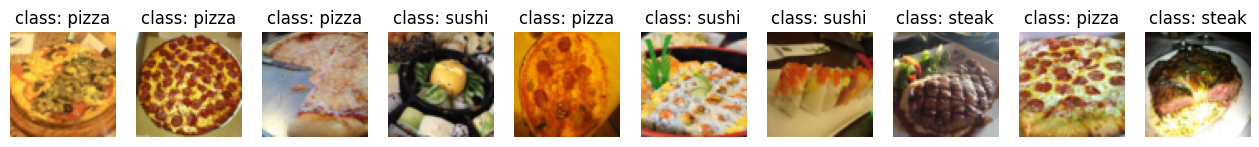

In [23]:
display_random_images(train_data_custom, classes= train_data_custom.classes, n=15)

**Note:** Since our custom dataset is inheriting fom Dataset class -> we can use a DataLoader

## A deeper dive in data augmentation

**Note:** **Data augmentation** is the process of altering your data in such a way that you artificially increase the diversity of your training set. -> Better generalization

In [24]:
from torchvision import transforms

aug_train_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

aug_test_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

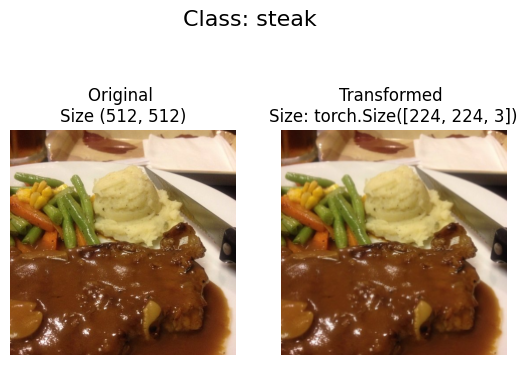

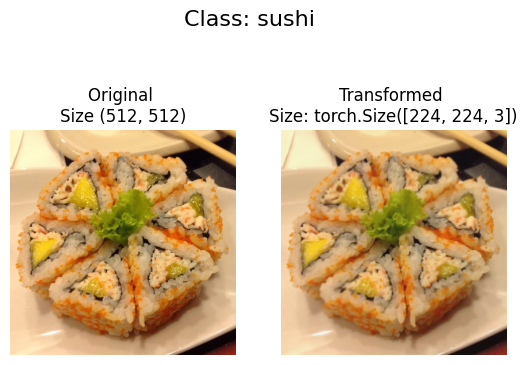

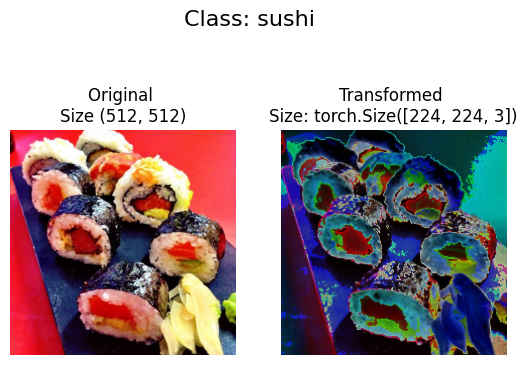

In [25]:
# Let's test our data augmentation out!
plot_transformed_images(image_path_list, aug_train_transforms, n=3, seed=None)

# Let's start training!

In [26]:
# Simple transform: No data augmentation
simple_transform= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [27]:
# functionize data preprocessing
def data_preprocessing(parent_dir: Path, transform: transforms.Compose):
  train_dir= parent_dir / "train"
  test_dir= parent_dir / "test"

  from torchvision import datasets
  train_data= datasets.ImageFolder(root=train_dir,
                                          transform=transform)
  test_data= datasets.ImageFolder(root=test_dir,
                                         transform=transform)
  import os
  from torch.utils.data import DataLoader

  BATCH_SIZE= 32
  NUM_WORKERS= os.cpu_count()
  print( f"Creating DataLoader with batch size {BATCH_SIZE} and {NUM_WORKERS} workers")

  train_dataloader= DataLoader(train_data, batch_size= BATCH_SIZE,
                               shuffle=True,
                               num_workers= NUM_WORKERS)
  test_dataloader= DataLoader(test_data, batch_size= BATCH_SIZE,
                               shuffle=False,
                               num_workers= NUM_WORKERS)
  return train_dataloader, test_dataloader, train_data, test_data

# CASE 0: Simple Use

train_dataloader_simple, test_dataloader_simple, train_data, test_data= data_preprocessing(image_path, simple_transform)


Creating DataLoader with batch size 32 and 2 workers


In [38]:
# TinyVGG model class

class TinyVGG(nn.Module):

  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) #default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units*16*16,
                  out_features= output_shape)
    )
  def forward(self, X: torch.Tensor):
    X= self.conv_block_1(X)
    X= self.conv_block_2(X)
    X= self.classifier(X)
    return X

torch.manual_seed(42)
model_0= TinyVGG(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)

model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [42]:
#Let's test a forward pass (for shape dimensions purposes)
img_batch, label_batch=next(iter(train_dataloader_simple))

img_single, label_single= img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

model_0.eval()
with torch.inference_mode():
  pred= model_0(img_single.to(device))

#print what's happening
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label: {label_single}\nReal label: {label_single}")


Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0705, 0.0640, 0.0410]], device='cuda:0')

Output prediction probabilities:
tensor([[0.3373, 0.3351, 0.3275]], device='cuda:0')

Output prediction label:
tensor([0], device='cuda:0')

Actual label: 1
Real label: 1


In [44]:
# Let's get an idea on the shapes going through our model with torchinfo
!pip install torchinfo
import torchinfo

from torchinfo import summary
summary(model_0, input_size=[32,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia